In [1]:
import pandas as pd
import librosa
import os
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import time

In [2]:
window_size = 1024
hop_length = 512
number_of_mels = 64
epochs = 20

In [3]:
sample_rate = 16_000
target_duration = 3.0
target_length = int(target_duration * sample_rate)
clips_dir = '../dataset/Clips'
features_dir = '../dataset/Features'

label_dict = {
    'prolongation': 0,
    'block': 1,
    'soundrep': 2,
    'wordrep': 3,
    'interjection': 4,
    'nospeech': 5
}

model_paths = []
for key, val in label_dict.items():
    model_paths.append(f'models/{key}_model_{window_size}_{hop_length}_{number_of_mels}_{epochs}.pth')

In [4]:
device = torch.device("cpu")
if torch.cuda.is_available():
   print("Using GPU")
   device = torch.device("cuda")
elif torch.mps.is_available():
   print("Using MPS device")
   device = torch.device("mps")

Using GPU


In [5]:
data = pd.read_csv("../dataset/SEP-28k_labels.csv", delimiter=",")

In [6]:
data.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech
0,HeStutters,0,0,31900320,31948320,0,0,0,0,0,0,0,0,3,1,0,0
1,HeStutters,0,1,31977120,32025120,0,0,0,0,0,0,0,0,3,1,0,0
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,0,0,0,3,0,0,0
3,HeStutters,0,3,35200640,35248640,0,0,1,0,0,0,0,0,2,0,0,0
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,0,0,0,3,0,0,0


In [7]:
# interested_rows = ['Unsure', 'PoorAudioQuality', 'Prolongation', 'Block', 'SoundRep', 'WordRep',
#                    'DifficultToUnderstand', 'Interjection', 'NoStutteredWords', 'NaturalPause',
#                    'Music', 'NoSpeech']

def transform_labels(row):
    return [
        int(row['Prolongation'] > 0),
        int(row['Block'] > 0),
        int(row['SoundRep'] > 0),
        int(row['WordRep'] > 0),
        int(row['Interjection'] > 0),
        int(row['NoSpeech'] > 0)
    ]

data['labels'] = data.apply(transform_labels, axis=1)
data['filepath'] = data.apply(
    lambda x: os.path.join(clips_dir, f"{x['Show']}/{x['EpId']}/{x['Show']}_{x['EpId']}_{x['ClipId']}.wav"), axis=1
)

In [8]:
data['filepath']

0         ../dataset/Clips/HeStutters/0/HeStutters_0_0.wav
1         ../dataset/Clips/HeStutters/0/HeStutters_0_1.wav
2         ../dataset/Clips/HeStutters/0/HeStutters_0_2.wav
3         ../dataset/Clips/HeStutters/0/HeStutters_0_3.wav
4         ../dataset/Clips/HeStutters/0/HeStutters_0_4.wav
                               ...                        
28172    ../dataset/Clips/WomenWhoStutter/109/WomenWhoS...
28173    ../dataset/Clips/WomenWhoStutter/109/WomenWhoS...
28174    ../dataset/Clips/WomenWhoStutter/109/WomenWhoS...
28175    ../dataset/Clips/WomenWhoStutter/109/WomenWhoS...
28176    ../dataset/Clips/WomenWhoStutter/109/WomenWhoS...
Name: filepath, Length: 28177, dtype: object

In [9]:
freq = dict()
rows_to_delete = []
for i in range(len(data)):
    try:
        y, sr = librosa.load(data.iloc[i]['filepath'], sr=sample_rate, mono=True)
    except FileNotFoundError as e:
        rows_to_delete.append(i)
        continue
        
    duration = librosa.get_duration(y=y, sr=sr)
    if duration not in freq:
        freq[duration] = 1
    else:
        freq[duration] += 1
print(f'{freq = }')

/tmp/ipykernel_20990/1435527838.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(data.iloc[i]['filepath'], sr=sample_rate, mono=True)
/home/kshku/Git/DADS/.venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


freq = {3.0: 20887, 2.704: 1, 2.9: 1, 2.63: 1, 2.8638125: 1, 2.5611875: 1, 2.7324375: 1, 2.692375: 1, 2.6928125: 1, 2.831: 1, 2.6331875: 1, 2.55: 3, 2.54: 1, 2.585: 1, 2.56: 1, 2.59: 1, 2.58: 1, 2.578: 1}


In [10]:
len(rows_to_delete)

7271

In [11]:
data = data.drop(rows_to_delete)
len(data)

20906

In [12]:
# def draw_log_frequency_power_spectogram(y, sr, hop_len=160, title='Log-frequency power spectogram'):
#     fig, ax = plt.subplots()
#     D = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=hop_length)), ref=np.max)
#     img = librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length, x_axis='time', ax=ax)
#     ax.set(title=title)
#     ax.label_outer()
#     fig.colorbar(img, ax=ax, format="%+2.f dB")

# def draw_melspectogram(y, sr, n_mels=number_of_mels, fmax=8000, title='Mel-frequency spectogram'):
#     fig, ax = plt.subplots()
#     S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=fmax)
#     S_dB = librosa.power_to_db(S, ref=np.max)
#     img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=fmax, ax=ax)
#     fig.colorbar(img, ax=ax, format='%+2.0f dB')
#     ax.set(title=title)

def draw_spectograms(y, sr, hop_len=hop_length, n_mels=number_of_mels, fmax=8000):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=hop_length)), ref=np.max)
    img = librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length, x_axis='time', ax=ax[0])
    ax[0].set(title="Log-frequency power spectogram")
    ax[0].label_outer()

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=fmax)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=fmax, ax=ax[1])
    ax[1].set(title='Mel-frequency spectogram')
    ax[1].label_outer()
    
    fig.colorbar(img, ax=ax, format="%+2.f dB")

row['Block'] = np.int64(2)
row['Block'] = np.int64(0)
row['Block'] = np.int64(0)
row['Block'] = np.int64(0)
row['Block'] = np.int64(0)


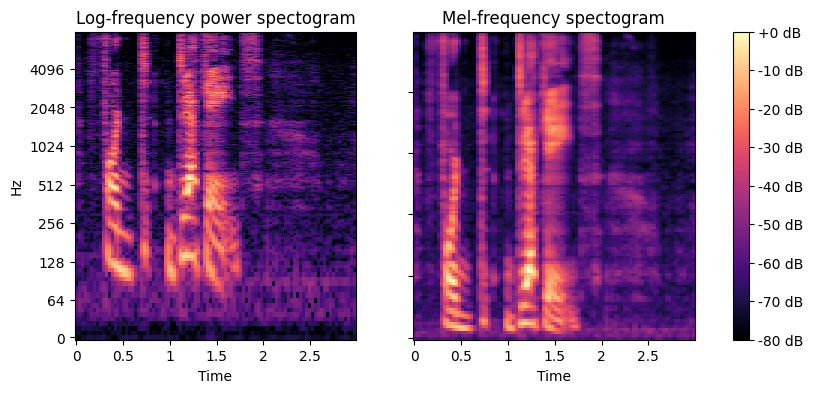

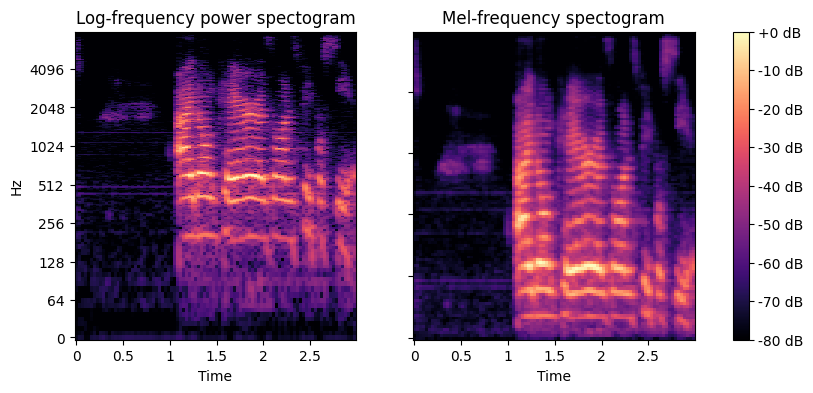

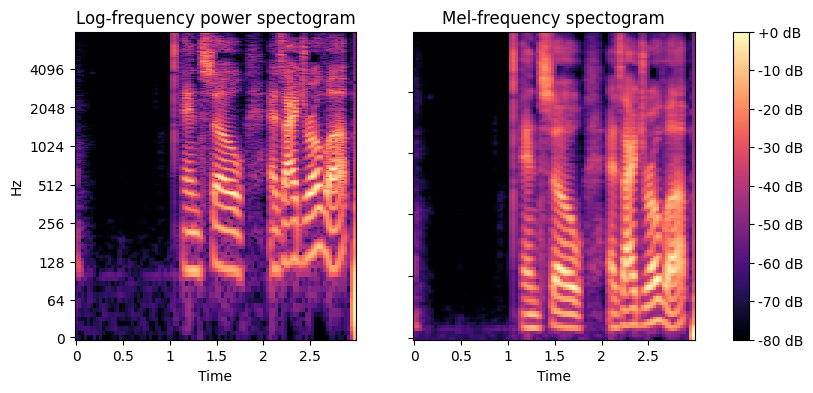

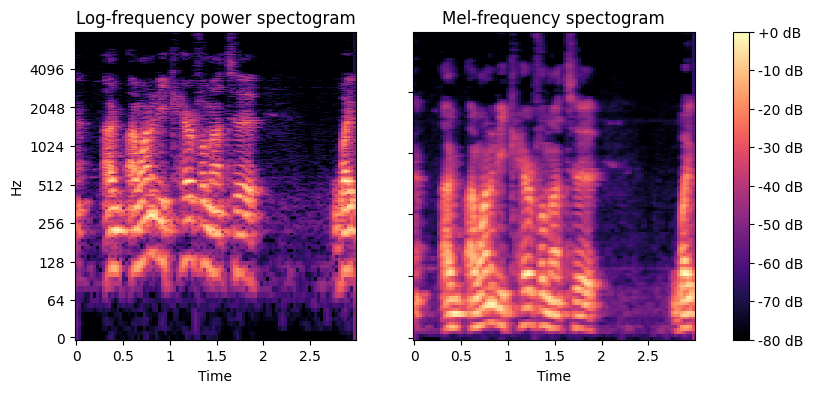

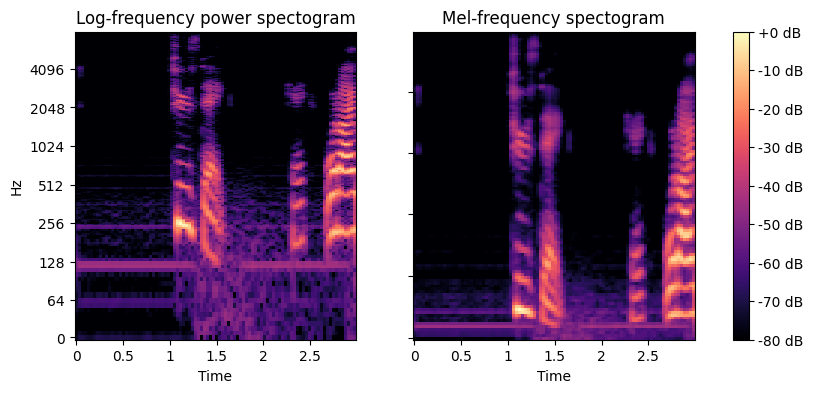

In [13]:
for i in range(5):
    row = data.iloc[random.randint(0, len(data))]
    y, sr = librosa.load(row['filepath'], sr=sample_rate, mono=True)
    # draw_log_frequency_power_spectogram(y, sr)
    # draw_melspectogram(y, sr)
    draw_spectograms(y, sr)
    print(f"{row['Block'] = }")

In [14]:
def pad_or_truncate(y, target_length=target_length):
    if len(y) < target_length:
        # Pad with zeros (silence) at the end
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width))
    elif len(y) > target_length:
        # Truncate
        y = y[:target_length]
    return y

In [15]:
def extract_features(audio_file, sr=sample_rate,
                     n_fft=window_size, hop_len=hop_length,
                     n_mels=number_of_mels, normalize=True, save_dir=None):
    try:
        y, _ = librosa.load(audio_file, sr=sr, mono=True)
    except Exception as e:
        raise ValueError(f"Invalid audio file: {audio_file} ({e})")
    y = pad_or_truncate(y)

    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_len, n_mels=n_mels)
    mels_db = librosa.power_to_db(mels, ref=np.max)

    if normalize:
        mean = np.mean(mels_db)
        std = np.std(mels_db) + 1e-10 # Avoid divide by zero
        mels_db = (mels_db - mean) / std

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(save_dir, base + ".npy")
        np.save(save_path, mels_db)
        return mels_db, save_path

    return mels_db

In [16]:
# mels, path = extract_features(data.iloc[random.randint(0, len(data))]['filepath'], save_dir=features_dir)
# mels.shape

In [17]:
base = os.path.splitext(os.path.basename(data.iloc[0]['filepath']))[0]
feature_files = []
if not os.path.exists(os.path.join(features_dir, base + ".npy")):
    for index, row in data.iterrows():
        _, path = extract_features(row['filepath'], save_dir=features_dir)
        feature_files.append(path)
else:
    for index, row in data.iterrows():
        base = os.path.splitext(os.path.basename(row['filepath']))[0]
        file_path = os.path.join(features_dir, base + ".npy")
        feature_files.append(file_path)
    
data['featurefile'] = feature_files

In [18]:
data.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech,labels,filepath,featurefile
0,HeStutters,0,0,31900320,31948320,0,0,0,0,0,0,0,0,3,1,0,0,"[0, 0, 0, 0, 0, 0]",../dataset/Clips/HeStutters/0/HeStutters_0_0.wav,../dataset/Features/HeStutters_0_0.npy
1,HeStutters,0,1,31977120,32025120,0,0,0,0,0,0,0,0,3,1,0,0,"[0, 0, 0, 0, 0, 0]",../dataset/Clips/HeStutters/0/HeStutters_0_1.wav,../dataset/Features/HeStutters_0_1.npy
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,0,0,0,3,0,0,0,"[0, 0, 0, 0, 0, 0]",../dataset/Clips/HeStutters/0/HeStutters_0_2.wav,../dataset/Features/HeStutters_0_2.npy
3,HeStutters,0,3,35200640,35248640,0,0,1,0,0,0,0,0,2,0,0,0,"[1, 0, 0, 0, 0, 0]",../dataset/Clips/HeStutters/0/HeStutters_0_3.wav,../dataset/Features/HeStutters_0_3.npy
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,0,0,0,3,0,0,0,"[0, 0, 0, 0, 0, 0]",../dataset/Clips/HeStutters/0/HeStutters_0_4.wav,../dataset/Features/HeStutters_0_4.npy


In [19]:
X = data['featurefile'].values.reshape(-1, 1)
y = np.stack(data['labels'].to_list(), dtype=np.float32)
# y = np.array([label[1] for label in data['labels']], dtype=np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                    # random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, 
                                                # random_state=42
)

train_df = pd.DataFrame({
    'feature_file': X_train.flatten(), 
    'labels': [list(row) for row in y_train]
})
val_df = pd.DataFrame({
    'feature_file': X_val.flatten(),
    'labels': [list(row) for row in y_val]
})
test_df = pd.DataFrame({
    'feature_file': X_test.flatten(),
    'labels': [list(row) for row in y_test]
})

In [20]:
class SEP28kDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mels_db = np.load(row['feature_file'])

        y = np.array(row['labels'], dtype=np.float32)
        
        return mels_db, y

In [21]:
train_dataset = SEP28kDataset(train_df)
val_dataset = SEP28kDataset(val_df)
test_dataset = SEP28kDataset(test_df)

In [22]:
batch_size = 32
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=12,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,          # no shuffle for validation
    num_workers=4,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,          # no shuffle for testing
    num_workers=4,
    pin_memory=pin_memory
)

In [23]:
class Model(nn.Module):
    def __init__(self, n_mels=number_of_mels):
        super(Model, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # shape: (batch, n_mels, time_frames) -> (batch, 1, n_mels, time_frames)
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.fc(x)
        return x

In [24]:
# Use label dict for model
models = [Model().to(device) for i in range(5)]

criterions = [nn.BCEWithLogitsLoss() for i in range(5)]
optimizers = [torch.optim.Adam(models[i].parameters(), lr=1e-3) for i in range(5)]

In [25]:
# model = Model()
# model = model.to(device)

# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
def train(index, models=models, criterions=criterions, optimizers=optimizers, epochs=epochs, train_loader=train_loader, val_loader=val_loader, device=device):
    model = models[index]
    criterion = criterions[index]
    optimizer = optimizers[index]
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # data is given in batch!
            labels = labels[:, index].unsqueeze(1)
            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
    
        avg_loss = running_loss / len(train_loader)
    
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                labels = labels[:, index].unsqueeze(1)
                output = model(inputs)
                preds = torch.sigmoid(output)
                preds = (preds > 0.5).int()
                correct += (preds == labels.int()).sum().item()
                total += labels.size(0)
    
        acc = 100 * correct / total
        
        print(f"Epoch [{epoch+1:2}/{epochs}], Loss: {avg_loss:f}, Validation Accuracy: {acc:f}%")

In [27]:
for i in range(5):
    start = time.time()
    print('-------------------------------------------------------------------')
    print(f"Training {model_paths[i]}...")
    train(i)
    end = time.time()
    print(f'{model_paths[i]} took {end - start:f} seconds')
    torch.save(models[i].state_dict(), model_paths[i])

-------------------------------------------------------------------
Training models/prolongation_model_1024_512_64_20.pth...
Epoch [ 1/20], Loss: 0.566448, Validation Accuracy: 72.735969%
Epoch [ 2/20], Loss: 0.549843, Validation Accuracy: 71.109694%
Epoch [ 3/20], Loss: 0.546097, Validation Accuracy: 73.054847%
Epoch [ 4/20], Loss: 0.541597, Validation Accuracy: 73.915816%
Epoch [ 5/20], Loss: 0.537277, Validation Accuracy: 74.298469%
Epoch [ 6/20], Loss: 0.533456, Validation Accuracy: 74.139031%
Epoch [ 7/20], Loss: 0.534998, Validation Accuracy: 70.663265%
Epoch [ 8/20], Loss: 0.530377, Validation Accuracy: 74.202806%
Epoch [ 9/20], Loss: 0.529209, Validation Accuracy: 72.672194%
Epoch [10/20], Loss: 0.526522, Validation Accuracy: 72.385204%
Epoch [11/20], Loss: 0.523678, Validation Accuracy: 74.521684%
Epoch [12/20], Loss: 0.520870, Validation Accuracy: 74.170918%
Epoch [13/20], Loss: 0.519783, Validation Accuracy: 74.362245%
Epoch [14/20], Loss: 0.518239, Validation Accuracy: 74.7

In [28]:
models = [Model().to(device) for i in range(5)]
for i in range(5):
    models[i].load_state_dict(torch.load(model_paths[i]))

In [29]:
def evaluate(index, models=models, test_loader=test_loader):
    model = models[index]
    
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels[:, index].unsqueeze(1)
            outputs = model(inputs)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).int()
    
            y_true.extend(labels.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())
    
    print(classification_report(y_true, y_pred, target_names=["No Block", "Block"], zero_division=0))
    print(confusion_matrix(y_true, y_pred))

In [30]:
for i in range(5):
    print('-------------------------------------------------------------------')
    print(f'Evaluating {model_paths[i]}...')
    evaluate(i)

-------------------------------------------------------------------
Evaluating models/prolongation_model_1024_512_64_20.pth...
              precision    recall  f1-score   support

    No Block       0.77      0.91      0.83      2152
       Block       0.66      0.40      0.50       984

    accuracy                           0.75      3136
   macro avg       0.71      0.65      0.66      3136
weighted avg       0.73      0.75      0.73      3136

[[1950  202]
 [ 593  391]]
-------------------------------------------------------------------
Evaluating models/block_model_1024_512_64_20.pth...
              precision    recall  f1-score   support

    No Block       0.61      0.88      0.72      1769
       Block       0.63      0.27      0.38      1367

    accuracy                           0.61      3136
   macro avg       0.62      0.57      0.55      3136
weighted avg       0.62      0.61      0.57      3136

[[1558  211]
 [1000  367]]
---------------------------------------------

In [38]:
def predict_from_audio(audio_file, index, models=models, device=device):
    model = models[i]
    prediction_texts = [
        ('No prolongation detected', 'Prolongation detected'),
        ('No block detected', 'Block detected'),
        ('No sound repetition detected', 'Sound repetition detected'),
        ('No word repetition detected', 'Word repetition detected'),
        ('No interjection detected', 'Interjection detected')
    ]
    
    mels_db = extract_features(audio_file)
    tensor = torch.tensor(mels_db, dtype=torch.float32).unsqueeze(0).to(device)
    # tensor = torch.tensor(mels_db).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output)
        label = int(prob > 0.5)

    return {"probability": prob.cpu().numpy().flatten(), "prediction": prediction_texts[index][label]}

In [39]:
row = data.iloc[random.randint(0, len(data))]
print(row)
for i in range(5):
    print(predict_from_audio(row['filepath'], i))

Show                                                       WomenWhoStutter
EpId                                                                   101
ClipId                                                                 131
Start                                                             21563840
Stop                                                              21611840
Unsure                                                                   0
PoorAudioQuality                                                         0
Prolongation                                                             0
Block                                                                    1
SoundRep                                                                 0
WordRep                                                                  0
DifficultToUnderstand                                                    0
Interjection                                                             0
NoStutteredWords         